# 03 · Model Benchmark

Compare Ridge / XGBoost / LightGBM per position using blocked time-series CV (one season held out per fold). The ensemble picks different winners per position — GKP is nearly flat, FWD is variance-driven.

In [3]:
from gaffer.providers.historical_csv import HistoricalCsvProvider
from gaffer.providers.fpl_api import LiveFplApiProvider
from gaffer.services.prediction_service import build_training_set
from gaffer.models.ridge import RidgePredictor
from gaffer.models.xgboost_model import XgbPredictor
from gaffer.models.lightgbm_model import LgbmPredictor
from gaffer.models.training import benchmark_predictors

td = build_training_set(LiveFplApiProvider(), HistoricalCsvProvider())
X = td.X.dropna()
# Raw predictors can't eat the string columns (team/opponent_team/position)
# that PositionEnsemble routes on internally — keep numeric + bool only here.
X = X.select_dtypes(include=['number', 'bool'])
y = td.y.loc[X.index]
print('Training set:', X.shape)


Training set: (184700, 27)


In [4]:
candidates = {
    'ridge': lambda: RidgePredictor(),
    'xgb': lambda: XgbPredictor(n_estimators=200, learning_rate=0.05),
    'lgbm': lambda: LgbmPredictor(n_estimators=300, learning_rate=0.05),
}
results = benchmark_predictors(candidates, X, y, td.seasons.loc[X.index])
results


,model,position,mean_rmse,std_rmse,mean_mae,n_folds
0,xgb,all,2.059522,0.093722,1.109316,6
1,lgbm,all,2.063331,0.097474,1.108515,6
2,ridge,all,2.090062,0.092369,1.179168,6


Text(0.5, 1.0, 'Blocked-CV benchmark: lower is better')

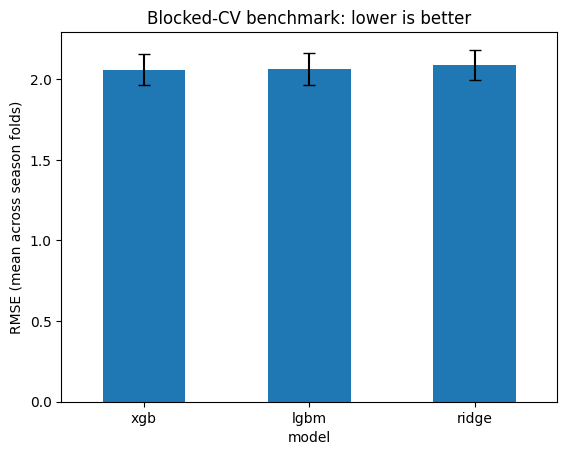

In [5]:
ax = results.plot.bar(
    x='model', y='mean_rmse', yerr='std_rmse',
    rot=0, legend=False, capsize=4,
)
ax.set_ylabel('RMSE (mean across season folds)')
ax.set_title('Blocked-CV benchmark: lower is better')


**Next:** `04_uncertainty_quantification.ipynb` — fit a quantile regressor for 80% intervals.